In [1]:
!pip install -q --upgrade "transformers>=4.46" "peft>=0.12" "accelerate>=0.30" \
    "scikit-learn>=1.3" "pandas" "pillow<12.0" "tqdm" "matplotlib" "opencv-python-headless"
!pip install -U "torchao>=0.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 136.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 139.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incom

In [2]:
import torch, sys
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__, "| CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("AVISO: nenhuma GPU detectada. Vá em Ambiente de execução > Alterar tipo > GPU.")

Python: 3.12.13
Torch: 2.11.0+cu128 | CUDA disponível: True
GPU: NVIDIA A100-SXM4-80GB
VRAM total: 85.1 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
CSV_PATH    = "/content/drive/MyDrive/BRSET/labels_brset.csv"
IMAGES_DIR  = "/content/drive/MyDrive/BRSET/fundus_photos"
OUTPUT_DIR  = "/content/drive/MyDrive/BRSET/retinascan_cbis/exp_dr_binary_metadata_patch_all_images_robust_circle_no_clahe"

TASK_NAME   = "DR (Normal vs Diabetic Retinopathy)"
TARGET_COL  = "diabetic_retinopathy"
POS_LABEL_NAME = "Diabetic Retinopathy"
NEG_LABEL_NAME = "Normal"

MODEL_NAME  = "facebook/dinov3-vitb16-pretrain-lvd1689m"
IMAGE_SIZE  = 512

USE_ROBUST_CIRCLE_CROP = True
CIRCLE_CROP_PADDING = 1.03
CIRCLE_DETECT_MAX_SIDE = 768
PRE_RESIZE_BEFORE_CROP = True
PRE_RESIZE_MAX_SIDE = 1200
USE_CLAHE = False
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

BATCH_SIZE        = 16
GRAD_ACCUM_STEPS  = 4
NUM_WORKERS       = 8
EPOCHS            = 50
PATIENCE          = 7
LR                = 1e-4
WEIGHT_DECAY      = 1e-4
MAX_GRAD_NORM     = 1.0

LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

FOCAL_GAMMA       = 1.0
CLASS_WEIGHT_BETA = 0.999
USE_OVERSAMPLING  = False
USE_AMP           = True

EXCLUDE_INADEQUATE_QUALITY = False

N_FOLDS     = 3
VAL_SIZE    = 0.15
N_BOOT      = 1000
SEED        = 42

USE_METADATA_IMAGE_PATCH = True
META_PATCH_SIZE = 32
META_PATCH_QUAD = 16

In [5]:
import os, json, random
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import cv2
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, roc_curve, classification_report,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm
from peft import LoraConfig, get_peft_model
from transformers import AutoModel

In [6]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [7]:
def _largest_component_mask(mask: np.ndarray) -> np.ndarray:
    """Mantém apenas o maior componente conectado da máscara binária."""
    mask = mask.astype("uint8")
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return mask.astype(bool)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return labels == largest


def _resize_for_detection(img: np.ndarray, max_side: int = 768):
    """Reduz a imagem para detectar o círculo mais rapidamente e retorna a escala."""
    H, W = img.shape[:2]
    max_dim = max(H, W)

    if max_dim <= max_side:
        return img, 1.0

    scale = float(max_side) / float(max_dim)
    new_w = max(1, int(round(W * scale)))
    new_h = max(1, int(round(H * scale)))
    small = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return small, scale


def detect_fundus_square(
    pil_img: Image.Image,
    padding: float = 1.03,
    return_mask: bool = False,
    detect_max_side: int = None,
):
    """Detecta a região retinal e retorna crop quadrado baseado no círculo envolvente.

    Versão otimizada:
    - a detecção do círculo é feita em uma cópia reduzida da imagem;
    - centro e raio são reescalados para a resolução original;
    - evita passar milhões de pixels para `cv2.minEnclosingCircle`, que era o gargalo.
    """
    img = np.array(pil_img.convert("RGB"))
    H, W = img.shape[:2]

    if detect_max_side is None:
        detect_max_side = int(CIRCLE_DETECT_MAX_SIDE)

    if H < 10 or W < 10:
        info = {
            "status": "too_small",
            "cx": W / 2,
            "cy": H / 2,
            "radius": min(H, W) / 2,
            "side": min(H, W),
            "detect_scale": 1.0,
            "mask_area_frac": 0.0,
        }
        mask_full = np.zeros((H, W), dtype=bool)
        return (pil_img, info, mask_full) if return_mask else (pil_img, info)

    small, scale = _resize_for_detection(img, max_side=detect_max_side)
    hS, wS = small.shape[:2]

    hsv = cv2.cvtColor(small, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)

    s = hsv[..., 1]
    v = hsv[..., 2]

    v_thr = max(10, int(np.percentile(v, 1)) + 5)
    gray_thr = max(10, int(np.percentile(gray, 1)) + 5)

    mask_bright = (v > v_thr) | (gray > gray_thr)
    mask_color = s > 8
    mask = mask_bright & (mask_color | (gray > 25))

    mask = mask.astype("uint8") * 255

    k_open = max(3, int(round(min(hS, wS) * 0.010)))
    k_close = max(9, int(round(min(hS, wS) * 0.035)))
    if k_open % 2 == 0:
        k_open += 1
    if k_close % 2 == 0:
        k_close += 1

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_open, k_open))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_close, k_close))

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

    mask_bool_small = _largest_component_mask(mask > 0)

    if mask_bool_small.sum() < 0.05 * hS * wS:
        gray_fallback = gray > 10
        gray_fallback = cv2.morphologyEx(
            gray_fallback.astype("uint8") * 255,
            cv2.MORPH_CLOSE,
            kernel_close,
        ) > 0
        mask_bool_small = _largest_component_mask(gray_fallback)

    ys, xs = np.where(mask_bool_small)

    if len(xs) < 10:
        cx_small, cy_small = wS / 2.0, hS / 2.0
        radius_small = max(hS, wS) / 2.0
        status = "fallback_full_image"
    else:
        if len(xs) > 50000:
            idx = np.linspace(0, len(xs) - 1, 50000).astype(int)
            xs_fit = xs[idx]
            ys_fit = ys[idx]
        else:
            xs_fit = xs
            ys_fit = ys

        pts = np.column_stack([xs_fit, ys_fit]).astype(np.float32)
        (cx_small, cy_small), radius_small = cv2.minEnclosingCircle(pts)
        status = "ok"

    inv_scale = 1.0 / float(scale)
    cx = float(cx_small * inv_scale)
    cy = float(cy_small * inv_scale)
    radius = float(radius_small * inv_scale)

    side = int(np.ceil(2.0 * radius * float(padding)))
    side = max(16, side)

    max_reasonable_side = int(np.ceil(1.25 * max(H, W)))
    if side > max_reasonable_side:
        side = max_reasonable_side
        status = status + "_side_clipped"

    x0 = int(round(cx - side / 2))
    y0 = int(round(cy - side / 2))
    x1 = x0 + side
    y1 = y0 + side

    src_x0 = max(x0, 0)
    src_y0 = max(y0, 0)
    src_x1 = min(x1, W)
    src_y1 = min(y1, H)

    crop = np.zeros((side, side, 3), dtype=np.uint8)

    dst_x0 = src_x0 - x0
    dst_y0 = src_y0 - y0
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    dst_y1 = dst_y0 + (src_y1 - src_y0)

    if src_x1 > src_x0 and src_y1 > src_y0:
        crop[dst_y0:dst_y1, dst_x0:dst_x1] = img[src_y0:src_y1, src_x0:src_x1]

    info = {
        "status": status,
        "cx": float(cx),
        "cy": float(cy),
        "radius": float(radius),
        "side": int(side),
        "x0": int(x0),
        "y0": int(y0),
        "x1": int(x1),
        "y1": int(y1),
        "mask_area_frac": float(mask_bool_small.mean()),
        "detect_scale": float(scale),
        "detect_shape": (int(hS), int(wS)),
    }

    crop_img = Image.fromarray(crop)

    if return_mask:
        return crop_img, info, mask_bool_small

    return crop_img, info


def pre_resize_before_crop(pil_img: Image.Image, max_side: int = None) -> Image.Image:
    """Reduz a imagem ainda no carregamento antes do crop/CLAHE.

    Como a entrada final do DINOv3 será 512×512, não precisamos manter imagens
    enormes no pipeline de CPU. Este passo é o que deixa o Dataset viável para treino.
    """
    if not PRE_RESIZE_BEFORE_CROP:
        return pil_img
    if max_side is None:
        max_side = int(PRE_RESIZE_MAX_SIDE)

    img = pil_img.copy()
    img.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    return img


def robust_circle_crop(pil_img: Image.Image) -> Image.Image:
    if not USE_ROBUST_CIRCLE_CROP:
        return pil_img
    crop_img, _ = detect_fundus_square(
        pil_img,
        padding=CIRCLE_CROP_PADDING,
        return_mask=False,
        detect_max_side=CIRCLE_DETECT_MAX_SIDE,
    )
    return crop_img


def apply_clahe_pil(pil_img: Image.Image) -> Image.Image:
    """Aplica CLAHE no canal L do espaço LAB."""
    if not USE_CLAHE:
        return pil_img

    img = np.array(pil_img.convert("RGB"))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=float(CLAHE_CLIP_LIMIT),
        tileGridSize=tuple(CLAHE_TILE_GRID_SIZE),
    )
    l2 = clahe.apply(l)

    lab2 = cv2.merge([l2, a, b])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2)


def build_transforms(image_size: int = 512, train: bool = True) -> transforms.Compose:
    if train:
        return transforms.Compose([
            transforms.Lambda(robust_circle_crop),
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
        ])
    return transforms.Compose([
        transforms.Lambda(robust_circle_crop),
        transforms.Resize((image_size, image_size), antialias=True),
        transforms.ToTensor(),
    ])


def _truthy_from_any(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return 1.0 if float(x) > 0 else 0.0
    s = str(x).strip().lower()
    if s in {"1", "true", "yes", "y", "sim", "male", "m", "positive", "positivo"}:
        return 1.0
    if s in {"0", "false", "no", "n", "não", "nao", "negative", "negativo"}:
        return 0.0
    return np.nan


def infer_diabetes_series(df: pd.DataFrame) -> pd.Series:
    if "diabetes" in df.columns:
        return df["diabetes"].apply(_truthy_from_any).astype("float32")
    if "comorbidities" in df.columns:
        has_info = df["comorbidities"].notna() & df["comorbidities"].astype(str).str.strip().ne("")
        has_dm = df["comorbidities"].fillna("").astype(str).str.lower().str.contains("diabet")
        out = pd.Series(np.nan, index=df.index, dtype="float32")
        out.loc[has_info] = 0.0
        out.loc[has_dm] = 1.0
        return out
    return pd.Series(np.nan, index=df.index, dtype="float32")


def infer_hypertension_series(df: pd.DataFrame) -> pd.Series:
    for col in ["hypertension", "systemic_hypertension"]:
        if col in df.columns:
            return df[col].apply(_truthy_from_any).astype("float32")
    if "comorbidities" in df.columns:
        has_info = df["comorbidities"].notna() & df["comorbidities"].astype(str).str.strip().ne("")
        has_ht = df["comorbidities"].fillna("").astype(str).str.lower().str.contains("hypertens|hipertens")
        out = pd.Series(np.nan, index=df.index, dtype="float32")
        out.loc[has_info] = 0.0
        out.loc[has_ht] = 1.0
        return out
    return pd.Series(np.nan, index=df.index, dtype="float32")


def infer_sex_flags(df: pd.DataFrame):
    if "patient_sex" not in df.columns:
        z = pd.Series(np.nan, index=df.index, dtype="float32")
        return z.copy(), z.copy()

    s = df["patient_sex"].fillna("").astype(str).str.strip().str.lower()
    male = pd.Series(np.nan, index=df.index, dtype="float32")
    female = pd.Series(np.nan, index=df.index, dtype="float32")
    male_mask = s.isin(["1", "m", "male", "masculino", "homem"])
    female_mask = s.isin(["2", "f", "female", "feminino", "mulher"])
    male.loc[male_mask] = 1.0
    male.loc[female_mask] = 0.0
    female.loc[female_mask] = 1.0
    female.loc[male_mask] = 0.0
    return male, female


def add_fold_metadata_patch_features(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    age_col = "patient_age" if "patient_age" in train_df.columns else None
    if age_col is None:
        age_min, age_max = 0.0, 100.0
    else:
        train_age = pd.to_numeric(train_df[age_col], errors="coerce")
        if train_age.notna().any():
            age_min = float(train_age.min())
            age_max = float(train_age.max())
            if age_max <= age_min:
                age_max = age_min + 1.0
        else:
            age_min, age_max = 0.0, 100.0

    def _apply(d: pd.DataFrame) -> pd.DataFrame:
        d = d.copy()
        age = pd.to_numeric(d[age_col], errors="coerce") if age_col is not None else pd.Series(np.nan, index=d.index)
        d["meta_age_present"] = age.notna().astype("float32")
        age_filled = age.fillna(age_min)
        d["meta_age_norm01"] = ((age_filled - age_min) / (age_max - age_min)).clip(0, 1).astype("float32")
        male, female = infer_sex_flags(d)
        d["meta_is_male"] = male.astype("float32")
        d["meta_is_female"] = female.astype("float32")
        d["meta_diabetes_yes"] = infer_diabetes_series(d).astype("float32")
        d["meta_hypertension_yes"] = infer_hypertension_series(d).astype("float32")
        return d

    params = {"age_min_train": age_min, "age_max_train": age_max, "age_col": age_col}
    return _apply(train_df), _apply(val_df), _apply(test_df), params


def insert_metadata_patch(img: torch.Tensor, row: pd.Series,
                          patch_size: int = 32, quad: int = 16) -> torch.Tensor:
    """Insere o patch 32×32 no canto superior esquerdo antes da normalização."""
    out = img.clone()
    H, W = out.shape[-2:]
    ps = min(patch_size, H, W)
    q = min(quad, ps // 2)
    out[:, :ps, :ps] = 0.0

    age_present = float(row.get("meta_age_present", 0.0))
    age_norm = float(row.get("meta_age_norm01", 0.0))
    is_male = row.get("meta_is_male", np.nan)
    is_female = row.get("meta_is_female", np.nan)
    diab = row.get("meta_diabetes_yes", np.nan)
    hyper = row.get("meta_hypertension_yes", np.nan)

    out[0, 0:q, 0:q] = age_norm
    out[1, 0:q, 0:q] = 0.75 if age_present >= 0.5 else 0.25
    out[2, 0:q, 0:q] = 0.0

    x0 = ps - q
    out[0, 0:q, x0:ps] = 0.0
    if pd.isna(is_male) and pd.isna(is_female):
        out[1, 0:q, x0:ps] = 0.0
        out[2, 0:q, x0:ps] = 0.0
    elif not pd.isna(is_male) and float(is_male) >= 0.5:
        out[1, 0:q, x0:ps] = 0.0
        out[2, 0:q, x0:ps] = 0.5
    else:
        out[1, 0:q, x0:ps] = 0.5
        out[2, 0:q, x0:ps] = 0.5

    y0 = ps - q
    out[0, y0:ps, 0:q] = 0.25
    out[1, y0:ps, 0:q] = 0.0
    if pd.isna(diab):
        out[2, y0:ps, 0:q] = 0.0
    else:
        out[2, y0:ps, 0:q] = 0.75 if float(diab) >= 0.5 else 0.0

    out[0, y0:ps, x0:ps] = 0.0
    out[1, y0:ps, x0:ps] = 0.25
    if pd.isna(hyper):
        out[2, y0:ps, x0:ps] = 0.0
    else:
        out[2, y0:ps, x0:ps] = 0.75 if float(hyper) >= 0.5 else 0.0

    return out.clamp(0.0, 1.0)


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class BRSETBinaryDataset(Dataset):
    def __init__(self, df, images_dir, transform=None, image_ext=".jpg",
                 use_metadata_patch: bool = True, normalize: bool = True):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
        self.image_ext = image_ext
        self.use_metadata_patch = use_metadata_patch
        self.normalize = normalize

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.images_dir, f"{row['image_id']}{self.image_ext}")
        img = Image.open(path).convert("RGB")
        img = pre_resize_before_crop(img, max_side=PRE_RESIZE_MAX_SIDE)
        if self.transform is not None:
            img = self.transform(img)
        if self.use_metadata_patch:
            img = insert_metadata_patch(img, row, patch_size=META_PATCH_SIZE, quad=META_PATCH_QUAD)
        if self.normalize:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return img, int(row["label"])

In [8]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer("alpha", alpha)
        self.gamma = gamma

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        targets_oh = F.one_hot(targets, num_classes=logits.size(-1)).float()
        focal = (1.0 - probs) ** self.gamma
        ce = -targets_oh * log_probs
        return (self.alpha.unsqueeze(0) * focal * ce).sum(dim=-1).mean()


def compute_class_weights(labels: np.ndarray, beta: float = 0.999) -> torch.Tensor:
    """
    Effective-number class weighting (Cui et al.). É menos extremo que 1/frequência,
    o que ajuda quando também usamos oversampling.
    """
    counts = np.bincount(labels.astype(int), minlength=2).astype(float)
    counts = np.maximum(counts, 1.0)
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


@dataclass
class BinaryMetrics:
    auc_roc: float; auc_pr: float; f1: float
    precision: float; recall: float; specificity: float
    balanced_accuracy: float; accuracy: float; threshold: float
    tn: int; fp: int; fn: int; tp: int
    f1_class_0: float; f1_class_1: float
    precision_class_0: float; precision_class_1: float
    recall_class_0: float; recall_class_1: float
    macro_f1: float; weighted_f1: float

    def to_dict(self):
        return {
            "auc_roc": self.auc_roc, "auc_pr": self.auc_pr, "f1": self.f1,
            "precision": self.precision, "recall_sensitivity": self.recall,
            "specificity": self.specificity,
            "balanced_accuracy": self.balanced_accuracy,
            "accuracy": self.accuracy, "threshold": self.threshold,
            "tn": self.tn, "fp": self.fp, "fn": self.fn, "tp": self.tp,
            "f1_class_0": self.f1_class_0, "f1_class_1": self.f1_class_1,
            "precision_class_0": self.precision_class_0, "precision_class_1": self.precision_class_1,
            "recall_class_0": self.recall_class_0, "recall_class_1": self.recall_class_1,
            "macro_f1": self.macro_f1, "weighted_f1": self.weighted_f1,
        }


def youden_threshold(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    j = tpr - fpr
    idx = int(np.argmax(j))
    return float(thr[idx]) if np.isfinite(thr[idx]) else 0.5


def best_f1_threshold(y_true, y_score):
    """Escolhe threshold na validação maximizando F1. Nunca use no teste."""
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    candidates = np.unique(np.quantile(y_score, np.linspace(0.01, 0.99, 199)))
    if len(candidates) == 0:
        return 0.5
    f1s = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in candidates]
    return float(candidates[int(np.argmax(f1s))])


def compute_binary_metrics(y_true, y_score, threshold=None):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if threshold is None:
        threshold = best_f1_threshold(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / max(tn + fp, 1)

    report = classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=[NEG_LABEL_NAME, POS_LABEL_NAME],
        output_dict=True,
        zero_division=0,
    )

    return BinaryMetrics(
        auc_roc=float(roc_auc_score(y_true, y_score)),
        auc_pr=float(average_precision_score(y_true, y_score)),
        f1=float(f1_score(y_true, y_pred, zero_division=0)),
        precision=float(precision_score(y_true, y_pred, zero_division=0)),
        recall=float(recall_score(y_true, y_pred, zero_division=0)),
        specificity=float(spec),
        balanced_accuracy=float(balanced_accuracy_score(y_true, y_pred)),
        accuracy=float(accuracy_score(y_true, y_pred)),
        threshold=float(threshold),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
        f1_class_0=float(report[NEG_LABEL_NAME]["f1-score"]),
        f1_class_1=float(report[POS_LABEL_NAME]["f1-score"]),
        precision_class_0=float(report[NEG_LABEL_NAME]["precision"]),
        precision_class_1=float(report[POS_LABEL_NAME]["precision"]),
        recall_class_0=float(report[NEG_LABEL_NAME]["recall"]),
        recall_class_1=float(report[POS_LABEL_NAME]["recall"]),
        macro_f1=float(report["macro avg"]["f1-score"]),
        weighted_f1=float(report["weighted avg"]["f1-score"]),
    )


def bootstrap_ci(y_true, y_score, metric_fn, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true); stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            stats.append(float(metric_fn(y_true[idx], y_score[idx])))
        except ValueError:
            continue
    if not stats:
        return float("nan"), float("nan"), float("nan")
    arr = np.array(stats)
    return float(arr.mean()), float(np.quantile(arr, alpha/2)), float(np.quantile(arr, 1-alpha/2))

In [9]:
class DINOv3LoRAClassifier(nn.Module):
    """Backbone DINOv3 (HF) congelado + adapters LoRA + cabeça MLP binária."""

    def __init__(
        self,
        model_name="facebook/dinov3-vitb16-pretrain-lvd1689m",
        num_classes=2,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
        target_modules=None,
        head_dropout=0.1,
        freeze_backbone=True,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        if target_modules is None:
            target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj"]

        lora_cfg = LoraConfig(
            r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
            target_modules=target_modules, bias="none", task_type=None,
        )
        self.backbone = get_peft_model(self.backbone, lora_cfg)

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(head_dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 5:, :].mean(dim=1)
        return self.head(pooled)

    def trainable_parameter_count(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

In [10]:
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    hf_token = os.environ.get('HF_TOKEN')

if not hf_token:
    raise ValueError(
        "HF_TOKEN não encontrado.\n"
        "Acesse https://huggingface.co/settings/tokens, crie um token de leitura,\n"
        "aceite a licença em https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m\n"
        "e adicione o token em Colab → Secrets → HF_TOKEN."
    )
print("HF_TOKEN carregado.")

_dbg = AutoModel.from_pretrained(MODEL_NAME)
_linear_names = sorted(set(
    n.split('.')[-1] for n, m in _dbg.named_modules() if isinstance(m, nn.Linear)
))
print("Nomes de Linear encontrados no DINOv3 (use esses em target_modules):")
print(_linear_names)
del _dbg

HF_TOKEN carregado.


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Nomes de Linear encontrados no DINOv3 (use esses em target_modules):
['down_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']


In [11]:
ALL_PATHOLOGY_COLS = [
    "diabetic_retinopathy",
    "diabetic_macular_edema",
    "macular_edema",
    "scar",
    "nevus",
    "amd",
    "vascular_occlusion",
    "hypertensive_retinopathy",
    "drusens",
    "hemorrhage",
    "retinal_detachment",
    "myopic_fundus",
    "increased_cup_disc",
    "other",
]


def _to_binary_series(s: pd.Series) -> pd.Series:
    """Torna robusto a CSVs com 0/1, True/False, strings ou NaN."""
    if s.dtype == bool:
        return s.astype(int)
    return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)


def filter_quality_brset(df: pd.DataFrame, exclude_inadequate: bool = True) -> pd.DataFrame:
    """Remove imagens problemáticas do BRSET antes de montar Normal vs alvo.

    No labels_brset.csv usado aqui, não há coluna chamada `inadequates`.
    A coluna equivalente é `quality`, com valores `Adequate`/`Inadequate`.
    Ela é derivada dos critérios `focus`, `Illuminaton`, `image_field` e `artifacts`:
    valor 2 em qualquer um desses critérios marca a imagem como inadequada.
    """
    if not exclude_inadequate:
        print("Filtro de qualidade desativado: usando imagens Adequate + Inadequate.")
        return df.copy()

    df = df.copy()
    n0 = len(df)

    if "quality" in df.columns:
        keep = df["quality"].astype(str).str.lower().eq("adequate")
        reason = "quality == 'Adequate'"
    else:
        quality_cols = [c for c in ["focus", "Illuminaton", "illumination", "image_field", "artifacts"] if c in df.columns]
        if not quality_cols:
            print("[aviso] Não encontrei coluna `quality` nem critérios de qualidade; nenhum filtro aplicado.")
            return df
        keep = ~(df[quality_cols].apply(pd.to_numeric, errors="coerce") == 2).any(axis=1)
        reason = f"nenhum critério inadequado em {quality_cols}"

    out = df[keep].reset_index(drop=True)
    print(f"Filtro de qualidade ({reason}): removidas {n0 - len(out)} de {n0} imagens ({(n0-len(out))/n0:.1%}).")
    return out

def build_binary_dataframe(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df.copy()
    present = [c for c in ALL_PATHOLOGY_COLS if c in df.columns]
    missing = [c for c in ALL_PATHOLOGY_COLS if c not in df.columns]
    if missing:
        print(f"[aviso] Colunas patológicas ausentes no CSV: {missing}")
    if target_col not in df.columns:
        raise ValueError(f"Coluna alvo '{target_col}' não está no CSV.")

    for c in present:
        df[c] = _to_binary_series(df[c])

    normal_mask = (df[present].sum(axis=1) == 0)
    pos_mask = df[target_col] == 1

    normal_df = df[normal_mask].assign(label=0)
    pos_df = df[pos_mask].assign(label=1)

    out = pd.concat([normal_df, pos_df], ignore_index=True)
    out = out.drop_duplicates(subset=["image_id"], keep="last").reset_index(drop=True)
    out["label"] = out["label"].astype(int)

    print(
        f"Normais: {(out['label']==0).sum()} | "
        f"Positivos: {(out['label']==1).sum()} | "
        f"Prevalência positiva: {out['label'].mean():.4f} | "
        f"Pacientes únicos: {out['patient_id'].nunique()}"
    )
    return out

In [12]:
raw_df = pd.read_csv(CSV_PATH)
print("Colunas do CSV:", list(raw_df.columns))
print(f"Total de linhas: {len(raw_df)}")

if "quality" in raw_df.columns:
    print("\nDistribuição da coluna quality:")
    print(raw_df["quality"].value_counts(dropna=False).to_string())

for c in ["focus", "Illuminaton", "image_field", "artifacts"]:
    if c in raw_df.columns:
        print(f"\n{c}:")
        print(raw_df[c].value_counts(dropna=False).sort_index().to_string())

raw_df = filter_quality_brset(raw_df, exclude_inadequate=EXCLUDE_INADEQUATE_QUALITY)

df = build_binary_dataframe(raw_df, target_col=TARGET_COL)
df.head()

Colunas do CSV: ['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']
Total de linhas: 16266

Distribuição da coluna quality:
quality
Adequate      14280
Inadequate     1986

focus:
focus
0        2
1    15723
2      541

Illuminaton:
Illuminaton
1    16182
2       84

image_field:
image_field
1    14865
2     1401

artifacts:
artifacts
1    16209
2       57
Filtro de qualidade desativado: usando imagens Adequate + Inadequate.
[aviso] Colunas patológicas ausentes no CSV: ['diabetic_macular_edema']
Normais: 8461 | Positivos: 1070 | Prevalência positiva: 0.1123 | Pa

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality,label
0,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,Adequate,0
1,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,Adequate,0
2,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,Adequate,0
3,img00006,3,Canon CR,22.0,diabetes1,11,yes,1,2,yes,...,0,0,0,0,0,0,0,0,Adequate,0
4,img00007,4,Canon CR,22.0,diabetes1,1,yes,1,1,yes,...,0,0,0,0,0,0,0,0,Adequate,0


In [13]:
n_pat = df["patient_id"].nunique()
n_img = len(df)
print(f"Total: {n_img} imagens de {n_pat} pacientes únicos "
      f"(média {n_img/n_pat:.2f} img/paciente)")

img_per_pat = df.groupby("patient_id").size()
print("\nImagens por paciente:")
print(img_per_pat.value_counts().sort_index().to_string())

labels_per_pat = df.groupby("patient_id")["label"].nunique()
n_conflict = (labels_per_pat > 1).sum()
print(f"\nPacientes com labels heterogêneos (OD vs OS): {n_conflict}")
if n_conflict > 0:
    print("  → ok mantê-los; apenas garante-se que todas as imagens vão pro mesmo split.")

dups = df["image_id"].duplicated().sum()
assert dups == 0, f"Há {dups} image_id duplicados — investigue antes de prosseguir."
print("\n✓ Sem image_id duplicados.")

Total: 9531 imagens de 5679 pacientes únicos (média 1.68 img/paciente)

Imagens por paciente:
1    1830
2    3847
3       1
4       1

Pacientes com labels heterogêneos (OD vs OS): 56
  → ok mantê-los; apenas garante-se que todas as imagens vão pro mesmo split.

✓ Sem image_id duplicados.


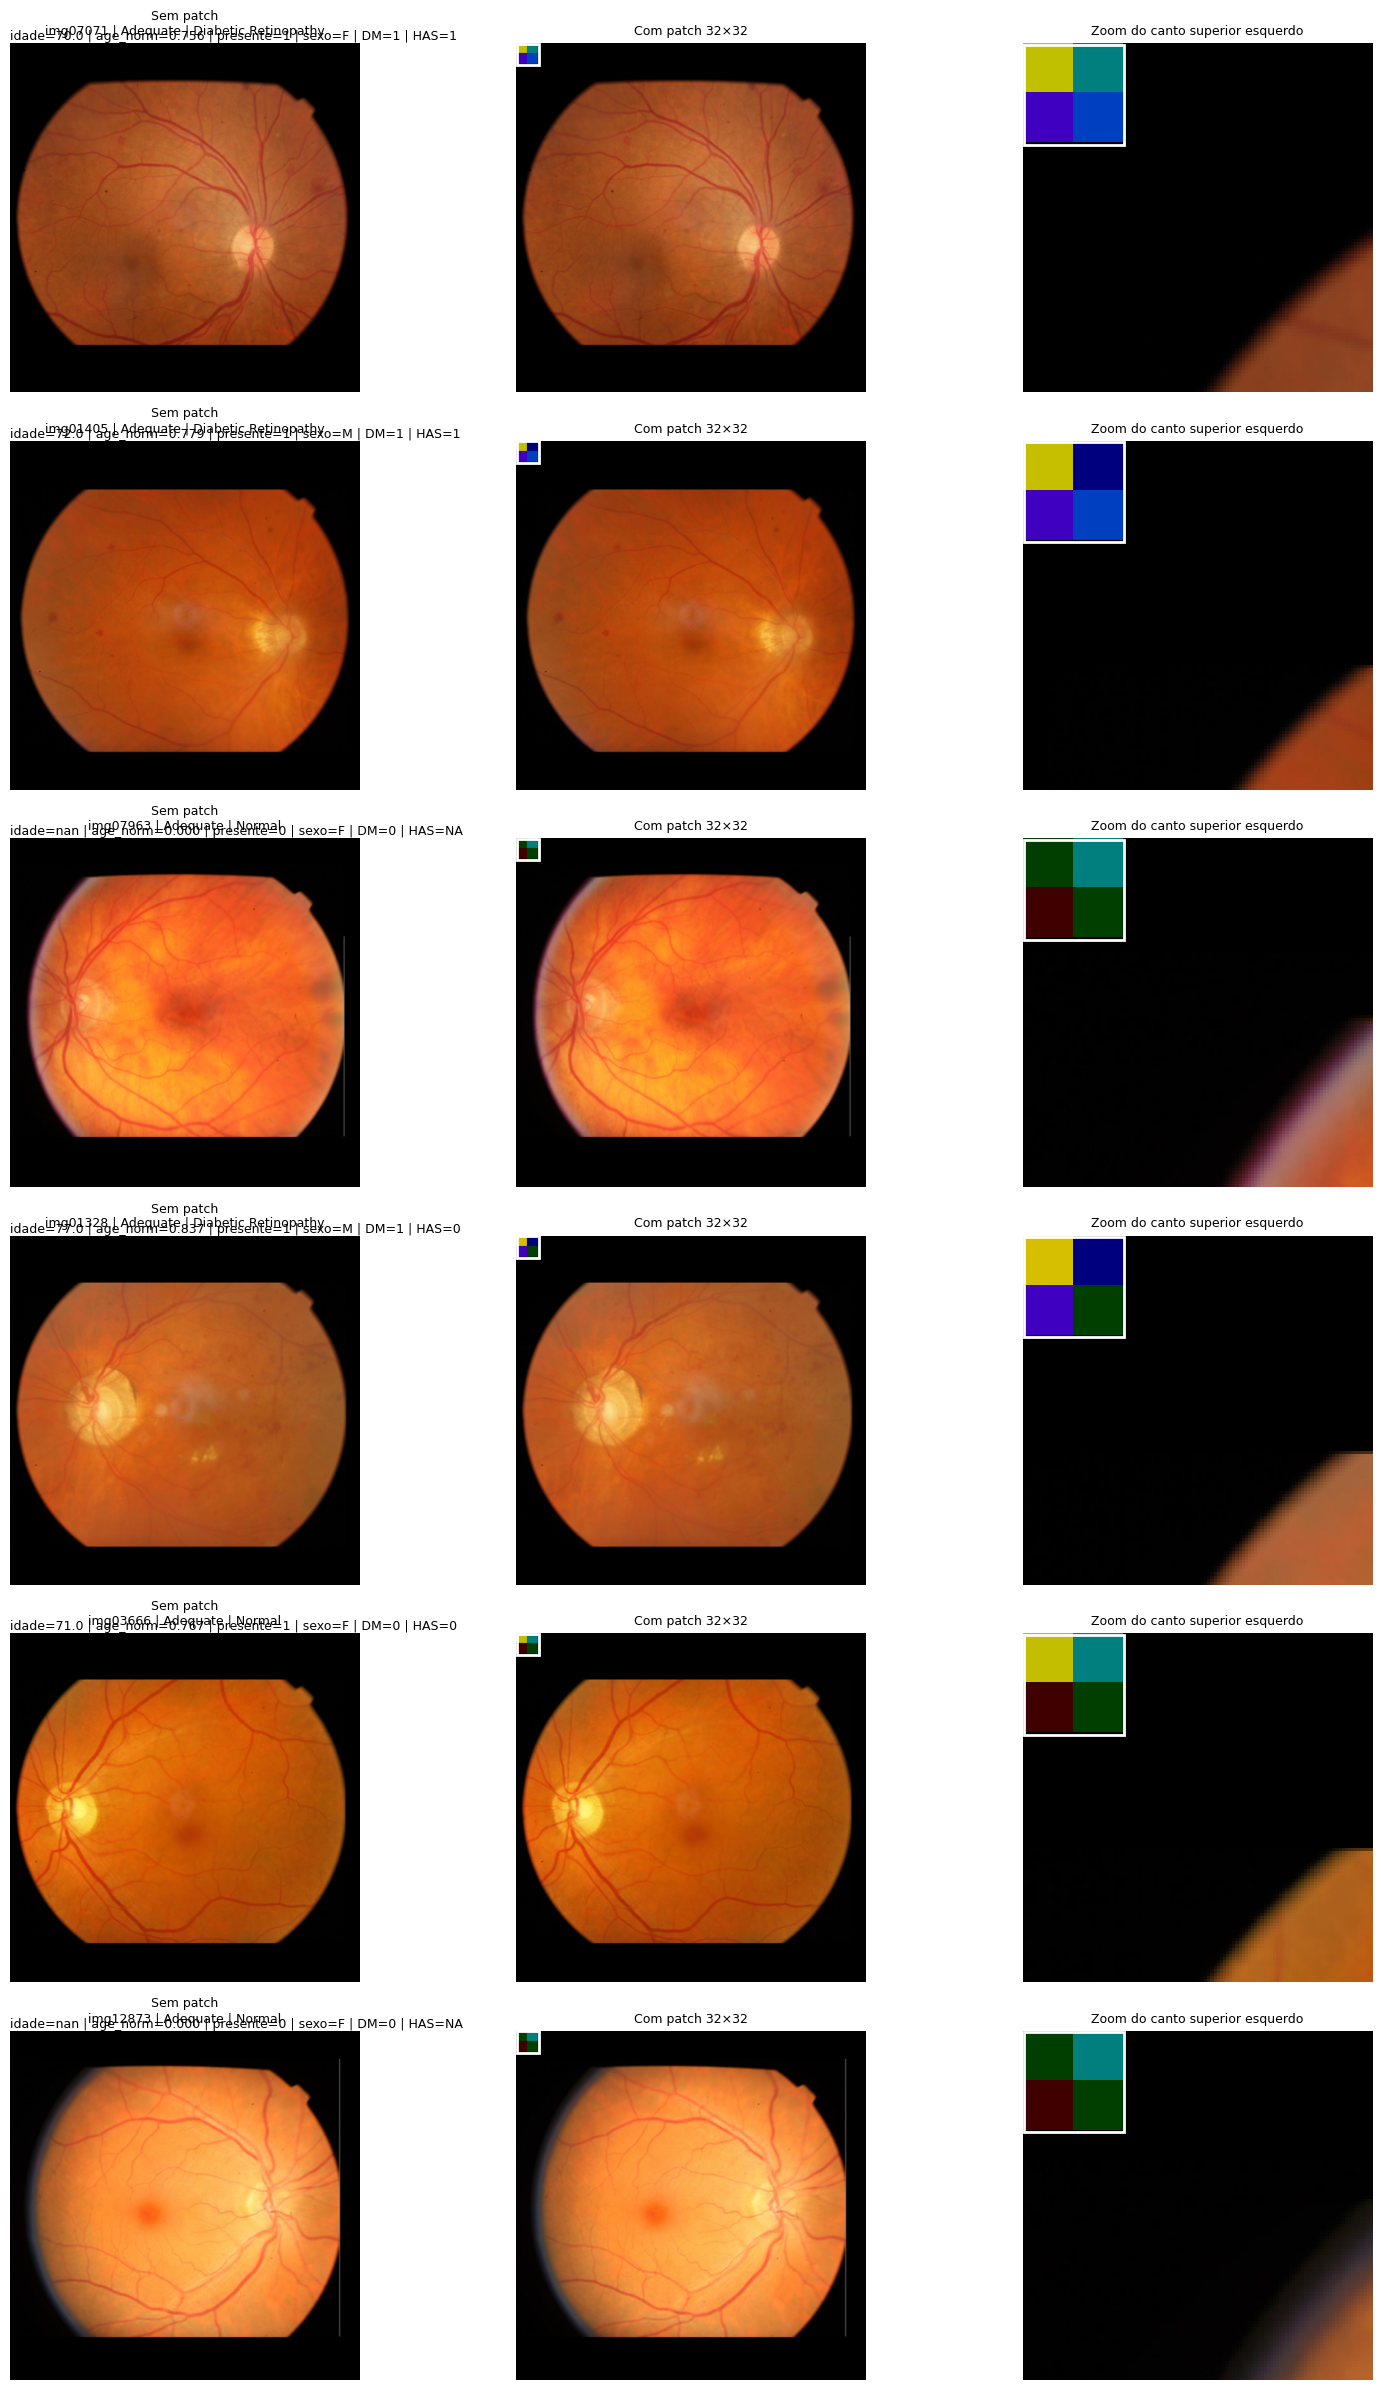

Parâmetros de normalização da idade usados na visualização: {'age_min_train': 5.0, 'age_max_train': 91.0, 'age_col': 'patient_age'}
Tamanho atual do patch: META_PATCH_SIZE=32, META_PATCH_QUAD=16


In [14]:
import matplotlib.pyplot as plt

def _safe_float(x, default=np.nan):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default


def _safe_int_or_na(x):
    try:
        if pd.isna(x):
            return "NA"
        return int(float(x))
    except Exception:
        return "NA"


def _format_sex(row):
    male_val = _safe_float(row.get("meta_is_male", np.nan))
    female_val = _safe_float(row.get("meta_is_female", np.nan))
    if not pd.isna(male_val) and male_val >= 0.5:
        return "M"
    if not pd.isna(female_val) and female_val >= 0.5:
        return "F"
    return "NA"


def _load_brset_image(image_id):
    candidates = [
        os.path.join(IMAGES_DIR, f"{image_id}.jpg"),
        os.path.join(IMAGES_DIR, f"{image_id}.jpeg"),
        os.path.join(IMAGES_DIR, f"{image_id}.png"),
        os.path.join(IMAGES_DIR, str(image_id)),
    ]
    for p in candidates:
        if os.path.exists(p):
            return Image.open(p).convert("RGB")
    raise FileNotFoundError(f"Imagem não encontrada para image_id={image_id}")


def _build_preview_split(df_in: pd.DataFrame):
    patient_df_preview = (
        df_in
        .groupby("patient_id")["label"]
        .max()
        .reset_index()
        .rename(columns={"label": "patient_label"})
    )

    outer_preview = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    tv_pat_idx, te_pat_idx = next(outer_preview.split(patient_df_preview, patient_df_preview["patient_label"]))
    tv_pat = patient_df_preview.iloc[tv_pat_idx].reset_index(drop=True)

    inner_n_splits = max(2, int(round(1 / VAL_SIZE)))
    inner_preview = StratifiedKFold(n_splits=inner_n_splits, shuffle=True, random_state=SEED)
    tr_pat_idx, va_pat_idx = next(inner_preview.split(tv_pat, tv_pat["patient_label"]))

    tr_pat = tv_pat.iloc[tr_pat_idx]
    va_pat = tv_pat.iloc[va_pat_idx]
    te_pat = patient_df_preview.iloc[te_pat_idx]

    tr_df_preview = df_in[df_in["patient_id"].isin(tr_pat["patient_id"])].reset_index(drop=True)
    va_df_preview = df_in[df_in["patient_id"].isin(va_pat["patient_id"])].reset_index(drop=True)
    te_df_preview = df_in[df_in["patient_id"].isin(te_pat["patient_id"])].reset_index(drop=True)
    return tr_df_preview, va_df_preview, te_df_preview


def preview_metadata_patch(
    df_in: pd.DataFrame,
    n_examples: int = 6,
    random_state: int = 42,
):
    tr_df_preview, va_df_preview, te_df_preview = _build_preview_split(df_in)

    tr_df_preview, va_df_preview, te_df_preview, meta_params_preview = add_fold_metadata_patch_features(
        tr_df_preview,
        va_df_preview,
        te_df_preview,
    )

    pool = pd.concat([tr_df_preview, va_df_preview], ignore_index=True)

    pos = pool[pool["label"] == 1]
    neg = pool[pool["label"] == 0]

    n_pos = min(max(1, n_examples // 2), len(pos))
    n_neg = min(max(1, n_examples - n_pos), len(neg))

    samples = []
    if n_pos > 0:
        samples.append(pos.sample(n=n_pos, random_state=random_state))
    if n_neg > 0:
        samples.append(neg.sample(n=n_neg, random_state=random_state + 1))

    if len(samples) == 0:
        raise ValueError("Não há exemplos disponíveis para visualização.")

    ex_df = (
        pd.concat(samples, ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    vis_tf = transforms.Compose([
        transforms.Lambda(lambda im: pre_resize_before_crop(im, max_side=PRE_RESIZE_MAX_SIDE)),
        transforms.Lambda(robust_circle_crop),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
        transforms.ToTensor(),
    ])

    fig, axes = plt.subplots(len(ex_df), 3, figsize=(14, 4 * len(ex_df)))
    if len(ex_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(ex_df.iterrows()):
        raw_img = _load_brset_image(row["image_id"])

        base = vis_tf(raw_img)
        patched = insert_metadata_patch(base, row, patch_size=META_PATCH_SIZE, quad=META_PATCH_QUAD)

        base_np = base.permute(1, 2, 0).numpy().clip(0, 1)
        patched_np = patched.permute(1, 2, 0).numpy().clip(0, 1)
        zoom_np = patched_np[:112, :112, :]

        age_raw = row.get("patient_age", np.nan)
        age_present = _safe_int_or_na(row.get("meta_age_present", np.nan))
        age_norm = row.get("meta_age_norm01", np.nan)
        sex = _format_sex(row)
        diab = _safe_int_or_na(row.get("meta_diabetes_yes", np.nan))
        hyper = _safe_int_or_na(row.get("meta_hypertension_yes", np.nan))
        lab = POS_LABEL_NAME if int(row["label"]) == 1 else NEG_LABEL_NAME
        quality_text = row.get("quality", "NA")

        axes[i, 0].imshow(base_np)
        axes[i, 0].set_title(f"Sem patch\n{row['image_id']} | {quality_text} | {lab}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(patched_np)
        axes[i, 1].add_patch(
            plt.Rectangle((0, 0), META_PATCH_SIZE, META_PATCH_SIZE,
                          fill=False, edgecolor="white", linewidth=2)
        )
        axes[i, 1].set_title(f"Com patch {META_PATCH_SIZE}×{META_PATCH_SIZE}", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(zoom_np, interpolation="nearest")
        axes[i, 2].add_patch(
            plt.Rectangle((0, 0), META_PATCH_SIZE, META_PATCH_SIZE,
                          fill=False, edgecolor="white", linewidth=2)
        )
        axes[i, 2].set_title("Zoom do canto superior esquerdo", fontsize=9)
        axes[i, 2].axis("off")

        axes[i, 0].text(
            0, -20,
            (
                f"idade={age_raw} | age_norm={age_norm:.3f} | presente={age_present} | "
                f"sexo={sex} | DM={diab} | HAS={hyper}"
            ),
            fontsize=9,
            va="top",
            transform=axes[i, 0].transData,
        )

    plt.tight_layout()
    plt.show()

    print("Parâmetros de normalização da idade usados na visualização:", meta_params_preview)
    print(f"Tamanho atual do patch: META_PATCH_SIZE={META_PATCH_SIZE}, META_PATCH_QUAD={META_PATCH_QUAD}")


preview_metadata_patch(
    df,
    n_examples=6,
    random_state=SEED,
)

In [15]:
def amp_dtype_for_device(device):
    if device.type != "cuda":
        return torch.float32
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def evaluate(model, loader, device, use_amp=True):
    model.eval()
    all_scores, all_labels = [], []
    amp_dtype = amp_dtype_for_device(device)
    amp_enabled = bool(use_amp and device.type == "cuda")
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=amp_dtype):
                logits = model(imgs)
            probs = torch.softmax(logits, dim=-1)[:, 1].float().cpu().numpy()
            all_scores.append(probs); all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_scores)


def make_train_loader(train_ds, train_df, batch_size, num_workers, use_oversampling, seed=42):
    if use_oversampling:
        labels = train_df["label"].values.astype(int)
        counts = np.bincount(labels, minlength=2)
        class_weights = 1.0 / np.maximum(counts, 1)
        sample_weights = class_weights[labels]
        generator = torch.Generator()
        generator.manual_seed(seed)
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
            generator=generator,
        )
        return DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                          num_workers=num_workers, pin_memory=True, persistent_workers=(num_workers > 0))
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                      num_workers=num_workers, pin_memory=True, persistent_workers=(num_workers > 0))


def train_one_fold(fold_idx, train_df, val_df, test_df, device, *,
                   images_dir, output_dir, model_name, image_size,
                   batch_size, num_workers, epochs, patience, lr, weight_decay,
                   lora_r, lora_alpha, lora_dropout, focal_gamma,
                   class_weight_beta, grad_accum_steps, max_grad_norm,
                   use_amp, use_oversampling, n_boot):

    out_dir = os.path.join(output_dir, f"fold_{fold_idx}")
    os.makedirs(out_dir, exist_ok=True)

    train_df, val_df, test_df, meta_patch_params = add_fold_metadata_patch_features(train_df, val_df, test_df)
    with open(os.path.join(out_dir, "metadata_patch_params.json"), "w") as f:
        json.dump(meta_patch_params, f, indent=2)

    train_tf = build_transforms(image_size=image_size, train=True)
    eval_tf = build_transforms(image_size=image_size, train=False)
    train_ds = BRSETBinaryDataset(train_df, images_dir, transform=train_tf, use_metadata_patch=USE_METADATA_IMAGE_PATCH)
    val_ds   = BRSETBinaryDataset(val_df,   images_dir, transform=eval_tf, use_metadata_patch=USE_METADATA_IMAGE_PATCH)
    test_ds  = BRSETBinaryDataset(test_df,  images_dir, transform=eval_tf, use_metadata_patch=USE_METADATA_IMAGE_PATCH)

    train_loader = make_train_loader(
        train_ds, train_df, batch_size, num_workers, use_oversampling, seed=SEED + fold_idx
    )
    val_loader  = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True, persistent_workers=(num_workers > 0))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True, persistent_workers=(num_workers > 0))

    model = DINOv3LoRAClassifier(
        model_name=model_name, num_classes=2,
        lora_r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
    ).to(device)
    trainable, total = model.trainable_parameter_count()
    print(f"[fold {fold_idx}] Parâmetros treináveis: {trainable:,} / {total:,} "
          f"({100*trainable/total:.2f}%)")

    class_weights = compute_class_weights(train_df["label"].values, beta=class_weight_beta).to(device)
    print(f"[fold {fold_idx}] Class weights suavizados (focal α): {class_weights.tolist()}")
    criterion = BinaryFocalLoss(alpha=class_weights, gamma=focal_gamma).to(device)

    head_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("head.")]
    lora_params = [p for n, p in model.named_parameters() if p.requires_grad and "lora_" in n]
    other_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("head.") and "lora_" not in n]
    param_groups = []
    if lora_params:
        param_groups.append({"params": lora_params, "lr": lr})
    if head_params:
        param_groups.append({"params": head_params, "lr": lr * 3.0})
    if other_params:
        param_groups.append({"params": other_params, "lr": lr})

    optim = torch.optim.AdamW(param_groups, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

    amp_enabled = bool(use_amp and device.type == "cuda")
    amp_dtype = amp_dtype_for_device(device)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled and amp_dtype == torch.float16)
    print(f"[fold {fold_idx}] AMP: {amp_enabled} | dtype: {amp_dtype}")

    ckpt_path = os.path.join(out_dir, "best_lora_head.pt")
    history   = []
    best_auc_pr = -1.0
    best_threshold = 0.5
    pat = 0

    for epoch in range(1, epochs + 1):
        model.train(); running = 0.0
        optim.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f"fold {fold_idx} | ep {epoch}/{epochs}")

        for step, (imgs, labels) in enumerate(pbar, start=1):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=amp_dtype):
                logits = model(imgs)
                loss   = criterion(logits, labels) / max(grad_accum_steps, 1)

            scaler.scale(loss).backward()
            if (step % grad_accum_steps == 0) or (step == len(train_loader)):
                if max_grad_norm is not None and max_grad_norm > 0:
                    scaler.unscale_(optim)
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], max_grad_norm
                    )
                scaler.step(optim)
                scaler.update()
                optim.zero_grad(set_to_none=True)

            running += loss.item() * max(grad_accum_steps, 1) * imgs.size(0)
            pbar.set_postfix(loss=f"{loss.item() * max(grad_accum_steps, 1):.4f}")

        scheduler.step()
        train_loss = running / len(train_ds)

        y_val, s_val = evaluate(model, val_loader, device, use_amp=use_amp)
        val_thr = best_f1_threshold(y_val, s_val)
        vm = compute_binary_metrics(y_val, s_val, threshold=val_thr)

        print(f"[fold {fold_idx} | ep {epoch:3d}] "
              f"loss={train_loss:.4f} | "
              f"val AUC={vm.auc_roc:.4f} | val AUC-PR={vm.auc_pr:.4f} | "
              f"val F1={vm.f1:.4f} | val sens={vm.recall:.4f} | val spec={vm.specificity:.4f} | "
              f"thr={vm.threshold:.4f}")

        history.append({
            "epoch": epoch, "train_loss": train_loss,
            **{f"val_{k}": v for k, v in vm.to_dict().items()},
        })

        if vm.auc_pr > best_auc_pr:
            delta = vm.auc_pr - best_auc_pr
            best_auc_pr = vm.auc_pr
            best_threshold = vm.threshold
            pat = 0
            lora_head_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
                if "lora_" in k or k.startswith("head.")
            }
            torch.save({
                "state_dict": lora_head_state,
                "best_threshold": best_threshold,
                "best_auc_pr": best_auc_pr,
                "epoch": epoch,
            }, ckpt_path)
            print(f"  ✓ Novo melhor AUC-PR val: {best_auc_pr:.4f} "
                  f"(+{delta:.4f}) | thr={best_threshold:.4f} → checkpoint salvo")
        else:
            pat += 1
            print(f"  ✗ AUC-PR val não melhorou. "
                  f"Paciência: {pat}/{patience}  (melhor: {best_auc_pr:.4f})")
            if pat >= patience:
                print(f"\n[fold {fold_idx}] ── Early stopping na época {epoch}. "
                      f"Melhor AUC-PR val = {best_auc_pr:.4f} ──\n")
                break

    pd.DataFrame(history).to_csv(os.path.join(out_dir, "history.csv"), index=False)

    if os.path.exists(ckpt_path):
        saved_blob = torch.load(ckpt_path, map_location=device)
        saved = saved_blob["state_dict"] if isinstance(saved_blob, dict) and "state_dict" in saved_blob else saved_blob
        best_threshold = float(saved_blob.get("best_threshold", best_threshold)) if isinstance(saved_blob, dict) else best_threshold
        current = model.state_dict()
        current.update(saved)
        model.load_state_dict(current)
        print(f"[fold {fold_idx}] Melhores pesos recarregados de {ckpt_path}; threshold val={best_threshold:.4f}")
    else:
        print(f"[fold {fold_idx}] AVISO: nenhum checkpoint encontrado. Usando pesos da última época.")

    y_test, s_test = evaluate(model, test_loader, device, use_amp=use_amp)
    tm = compute_binary_metrics(y_test, s_test, threshold=best_threshold)
    oracle_tm = compute_binary_metrics(y_test, s_test)
    print(f"\n[fold {fold_idx}] RESULTADO TESTE (threshold da validação):\n"
          f"  AUC-ROC={tm.auc_roc:.4f} | AUC-PR={tm.auc_pr:.4f} | F1={tm.f1:.4f} | "
          f"Sens={tm.recall:.4f} | Spec={tm.specificity:.4f} | "
          f"BalAcc={tm.balanced_accuracy:.4f} | Acc={tm.accuracy:.4f}\n"
          f"  Threshold val={tm.threshold:.4f} | TN={tm.tn} FP={tm.fp} FN={tm.fn} TP={tm.tp}\n"
          f"  Diagnóstico: melhor F1 possível no teste, se o threshold fosse escolhido no teste = {oracle_tm.f1:.4f} "
          f"(NÃO usar para comparação final)")

    auc_m, auc_lo, auc_hi = bootstrap_ci(y_test, s_test, roc_auc_score, n_boot=n_boot)
    pr_m,  pr_lo,  pr_hi  = bootstrap_ci(y_test, s_test, average_precision_score, n_boot=n_boot)
    thr = tm.threshold
    f1_at_thr = lambda yt, ys: f1_score(yt, (ys >= thr).astype(int), zero_division=0)
    f1_m, f1_lo, f1_hi = bootstrap_ci(y_test, s_test, f1_at_thr, n_boot=n_boot)

    print(f"  Bootstrap 95% CI (n={n_boot}): "
          f"AUC-ROC [{auc_lo:.4f}, {auc_hi:.4f}] | "
          f"AUC-PR [{pr_lo:.4f}, {pr_hi:.4f}] | "
          f"F1 [{f1_lo:.4f}, {f1_hi:.4f}]")

    summary = {
        "fold": fold_idx, **tm.to_dict(),
        "oracle_test_f1": oracle_tm.f1,
        "oracle_test_threshold": oracle_tm.threshold,
        "auc_roc_ci_low": auc_lo, "auc_roc_ci_high": auc_hi,
        "auc_pr_ci_low":  pr_lo,  "auc_pr_ci_high":  pr_hi,
        "f1_ci_low":      f1_lo,  "f1_ci_high":      f1_hi,
    }
    pd.DataFrame({
        "image_id":   test_df["image_id"].values,
        "patient_id": test_df["patient_id"].values,
        "label": y_test, "score": s_test,
        "threshold_from_val": best_threshold,
    }).to_csv(os.path.join(out_dir, "test_predictions.csv"), index=False)

    return summary, model

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

def _load_brset_image_for_crop_preview(image_id):
    candidates = [
        os.path.join(IMAGES_DIR, f"{image_id}.jpg"),
        os.path.join(IMAGES_DIR, f"{image_id}.jpeg"),
        os.path.join(IMAGES_DIR, f"{image_id}.png"),
        os.path.join(IMAGES_DIR, str(image_id)),
    ]

    for p in candidates:
        if os.path.exists(p):
            return Image.open(p).convert("RGB")

    raise FileNotFoundError(f"Imagem não encontrada para image_id={image_id}")


def preview_robust_circle_crop(
    df_in,
    n_examples=6,
    seed=SEED,
):
    pos = df_in[df_in["label"] == 1]
    neg = df_in[df_in["label"] == 0]

    n_pos = min(max(1, n_examples // 2), len(pos))
    n_neg = min(max(1, n_examples - n_pos), len(neg))

    parts = []

    if n_pos > 0:
        parts.append(pos.sample(n=n_pos, random_state=seed))

    if n_neg > 0:
        parts.append(neg.sample(n=n_neg, random_state=seed + 1))

    if parts:
        sample_df = (
            pd.concat(parts)
            .sample(frac=1, random_state=seed)
            .reset_index(drop=True)
        )
    else:
        sample_df = (
            df_in
            .sample(n=min(n_examples, len(df_in)), random_state=seed)
            .reset_index(drop=True)
        )

    resize_only = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    ])

    fig, axes = plt.subplots(
        len(sample_df),
        4,
        figsize=(18, 4.2 * len(sample_df)),
    )

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample_df.iterrows()):
        t0 = time.time()

        image_id = row["image_id"]
        raw_img_full = _load_brset_image_for_crop_preview(image_id)

        raw_img = pre_resize_before_crop(
            raw_img_full,
            max_side=PRE_RESIZE_MAX_SIDE,
        )

        raw_np = np.array(raw_img.convert("RGB"))

        crop_img, info, mask = detect_fundus_square(
            raw_img,
            padding=CIRCLE_CROP_PADDING,
            return_mask=True,
            detect_max_side=CIRCLE_DETECT_MAX_SIDE,
        )

        final_img = resize_only(crop_img)

        crop_np = np.array(crop_img) / 255.0
        final_np = np.array(final_img) / 255.0

        lab = POS_LABEL_NAME if int(row["label"]) == 1 else NEG_LABEL_NAME
        quality_text = row.get("quality", "NA")

        axes[i, 0].imshow(raw_np)
        axes[i, 0].set_title(
            f"Original pré-redimensionada\nimage_id={image_id} | {quality_text} | {lab}",
            fontsize=9,
        )
        axes[i, 0].axis("off")

        circ = patches.Circle(
            (info["cx"], info["cy"]),
            info["radius"],
            fill=False,
            linewidth=2,
            edgecolor="yellow",
        )
        axes[i, 0].add_patch(circ)

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(
            f"Máscara detectada\narea={info['mask_area_frac']:.3f}, status={info['status']}",
            fontsize=9,
        )
        axes[i, 1].axis("off")

        axes[i, 2].imshow(crop_np)
        axes[i, 2].set_title(
            f"Crop quadrado pelo círculo\nside={info['side']}, r={info['radius']:.1f}",
            fontsize=9,
        )
        axes[i, 2].axis("off")

        axes[i, 3].imshow(final_np)
        axes[i, 3].set_title(
            f"Resultado final {IMAGE_SIZE}×{IMAGE_SIZE}",
            fontsize=9,
        )
        axes[i, 3].axis("off")

        print(
            f"[crop preview] {image_id}: {time.time() - t0:.2f}s | "
            f"status={info['status']} | side={info['side']} | "
            f"detect_scale={info.get('detect_scale', 'NA')}"
        )

    plt.tight_layout()
    plt.show()


preview_robust_circle_crop(
    df,
    n_examples=6,
    seed=SEED,
)

Output hidden; open in https://colab.research.google.com to view.

In [17]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTPUT_DIR, exist_ok=True)


def assert_no_patient_leakage(tr_df, va_df, te_df, fold_idx):
    """Verifica explicitamente que nenhum patient_id aparece em mais de um split."""
    tr_pat = set(tr_df["patient_id"].unique())
    va_pat = set(va_df["patient_id"].unique())
    te_pat = set(te_df["patient_id"].unique())

    overlap_tr_va = tr_pat & va_pat
    overlap_tr_te = tr_pat & te_pat
    overlap_va_te = va_pat & te_pat

    assert not overlap_tr_va, f"[fold {fold_idx}] VAZAMENTO train↔val: {len(overlap_tr_va)} pacientes"
    assert not overlap_tr_te, f"[fold {fold_idx}] VAZAMENTO train↔test: {len(overlap_tr_te)} pacientes"
    assert not overlap_va_te, f"[fold {fold_idx}] VAZAMENTO val↔test: {len(overlap_va_te)} pacientes"

    n_tr_pat, n_va_pat, n_te_pat = len(tr_pat), len(va_pat), len(te_pat)
    n_tr_img, n_va_img, n_te_img = len(tr_df), len(va_df), len(te_df)
    print(
        f"[fold {fold_idx}] ✓ Sem vazamento de paciente.\n"
        f"           Pacientes:  train={n_tr_pat:5d} | val={n_va_pat:5d} | test={n_te_pat:5d} "
        f"(total único = {n_tr_pat + n_va_pat + n_te_pat})\n"
        f"           Imagens:    train={n_tr_img:5d} (pos={tr_df['label'].sum():4d}) | "
        f"val={n_va_img:5d} (pos={va_df['label'].sum():4d}) | "
        f"test={n_te_img:5d} (pos={te_df['label'].sum():4d})\n"
        f"           Img/paciente: train={n_tr_img/n_tr_pat:.2f} | "
        f"val={n_va_img/n_va_pat:.2f} | test={n_te_img/n_te_pat:.2f}"
    )


def build_patient_table(df):
    pat = df.groupby("patient_id")["label"].max().reset_index()
    pat = pat.rename(columns={"label": "patient_label"})
    print("Distribuição no nível do paciente:")
    print(pat["patient_label"].value_counts().sort_index().rename(index={0: NEG_LABEL_NAME, 1: POS_LABEL_NAME}).to_string())
    return pat


patient_df = build_patient_table(df)
outer = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_summaries = []

for fold_idx, (tv_pat_idx, te_pat_idx) in enumerate(
    outer.split(patient_df, patient_df["patient_label"])
):
    print(f"\n=========== FOLD {fold_idx} ===========")
    tv_pat = patient_df.iloc[tv_pat_idx].reset_index(drop=True)
    te_pat = patient_df.iloc[te_pat_idx].reset_index(drop=True)

    inner_n_splits = max(2, int(round(1 / VAL_SIZE)))
    inner = StratifiedKFold(n_splits=inner_n_splits, shuffle=True, random_state=SEED + fold_idx)
    in_tr_pat_idx, in_va_pat_idx = next(inner.split(tv_pat, tv_pat["patient_label"]))
    tr_pat = tv_pat.iloc[in_tr_pat_idx]
    va_pat = tv_pat.iloc[in_va_pat_idx]

    tr_df = df[df["patient_id"].isin(tr_pat["patient_id"])].reset_index(drop=True)
    va_df = df[df["patient_id"].isin(va_pat["patient_id"])].reset_index(drop=True)
    te_df = df[df["patient_id"].isin(te_pat["patient_id"])].reset_index(drop=True)

    assert_no_patient_leakage(tr_df, va_df, te_df, fold_idx)

    summary, _ = train_one_fold(
        fold_idx, tr_df, va_df, te_df, device,
        images_dir=IMAGES_DIR, output_dir=OUTPUT_DIR,
        model_name=MODEL_NAME, image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
        epochs=EPOCHS, patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY,
        lora_r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        focal_gamma=FOCAL_GAMMA, class_weight_beta=CLASS_WEIGHT_BETA,
        grad_accum_steps=GRAD_ACCUM_STEPS, max_grad_norm=MAX_GRAD_NORM,
        use_amp=USE_AMP, use_oversampling=USE_OVERSAMPLING, n_boot=N_BOOT,
    )
    fold_summaries.append(summary)
    torch.cuda.empty_cache()

Distribuição no nível do paciente:
patient_label
Normal                  5053
Diabetic Retinopathy     626

=========== FOLD 0 ===========
[fold 0] ✓ Sem vazamento de paciente.
           Pacientes:  train= 3245 | val=  541 | test= 1893 (total único = 5679)
           Imagens:    train= 5434 (pos= 611) | val=  901 (pos=  93) | test= 3196 (pos= 366)
           Img/paciente: train=1.67 | val=1.67 | test=1.69


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold 0] Parâmetros treináveis: 2,951,810 / 88,612,226 (3.33%)
[fold 0] Class weights suavizados (focal α): [0.6311283111572266, 1.3688716888427734]
[fold 0] AMP: True | dtype: torch.bfloat16


fold 0 | ep 1/50:   0%|          | 0/340 [00:00<?, ?it/s]

[fold 0 | ep   1] loss=0.0927 | val AUC=0.9749 | val AUC-PR=0.9220 | val F1=0.8876 | val sens=0.8495 | val spec=0.9926 | thr=0.5320
  ✓ Novo melhor AUC-PR val: 0.9220 (+1.9220) | thr=0.5320 → checkpoint salvo


...

[fold 2 | ep  22] loss=0.0034 | val AUC=0.9894 | val AUC-PR=0.9600 | val F1=0.9268 | val sens=0.8962 | val spec=0.9950 | thr=0.2320
  ✗ AUC-PR val não melhorou. Paciência: 5/7  (melhor: 0.9727)


fold 2 | ep 23/50:   0%|          | 0/343 [00:00<?, ?it/s]

[fold 2 | ep  23] loss=0.0015 | val AUC=0.9889 | val AUC-PR=0.9526 | val F1=0.9429 | val sens=0.9340 | val spec=0.9937 | thr=0.0273
  ✗ AUC-PR val não melhorou. Paciência: 6/7  (melhor: 0.9727)


fold 2 | ep 24/50:   0%|          | 0/343 [00:00<?, ?it/s]

[fold 2 | ep  24] loss=0.0026 | val AUC=0.9911 | val AUC-PR=0.9582 | val F1=0.9463 | val sens=0.9151 | val spec=0.9975 | thr=0.4962
  ✗ AUC-PR val não melhorou. Paciência: 7/7  (melhor: 0.9727)

[fold 2] ── Early stopping na época 24. Melhor AUC-PR val = 0.9727 ──

[fold 2] Melhores pesos recarregados de /content/drive/MyDrive/BRSET/retinascan_cbis/exp_dr_binary_metadata_patch_all_images_robust_circle_no_clahe/fold_2/best_lora_head.pt; threshold val=0.6610

[fold 2] RESULTADO TESTE (threshold da validação):
  AUC-ROC=0.9926 | AUC-PR=0.9555 | F1=0.9191 | Sens=0.9191 | Spec=0.9900 | BalAcc=0.9545 | Acc=0.9822
  Threshold val=0.6610 | TN=2773 FP=28 FN=28 TP=318
  Diagnóstico: melhor F1 possível no teste, se o threshold fosse escolhido no teste = 0.9159 (NÃO usar para comparação final)
  Bootstrap 95% CI (n=1000): AUC-ROC [0.9876, 0.9965] | AUC-PR [0.9336, 0.9739] | F1 [0.8954, 0.9391]


In [18]:
sdf = pd.DataFrame(fold_summaries)
sdf.to_csv(os.path.join(OUTPUT_DIR, "fold_test_metrics.csv"), index=False)

keys = ["auc_roc", "auc_pr", "f1", "precision", "recall_sensitivity",
        "specificity", "balanced_accuracy", "accuracy",
        "f1_class_0", "f1_class_1", "precision_class_0", "precision_class_1",
        "recall_class_0", "recall_class_1", "macro_f1", "weighted_f1"]
agg = {k: {"mean": float(sdf[k].mean()),
           "std":  float(sdf[k].std(ddof=0)),
           "min":  float(sdf[k].min()),
           "max":  float(sdf[k].max())} for k in keys}

with open(os.path.join(OUTPUT_DIR, "cv_summary.json"), "w") as f:
    json.dump({"task": TASK_NAME, "metrics": agg}, f, indent=2)
pd.DataFrame(agg).T.to_csv(os.path.join(OUTPUT_DIR, "cv_summary.csv"))

print(f"\n=========== RESUMO CV — {TASK_NAME} ===========")
for k, v in agg.items():
    print(f"  {k:25s}: {v['mean']:.4f} ± {v['std']:.4f}  (min={v['min']:.4f}, max={v['max']:.4f})")
sdf


=========== RESUMO CV — DR (Normal vs Diabetic Retinopathy) ===========
  auc_roc                  : 0.9903 ± 0.0025  (min=0.9869, max=0.9926)
  auc_pr                   : 0.9611 ± 0.0077  (min=0.9555, max=0.9720)
  f1                       : 0.9148 ± 0.0061  (min=0.9061, max=0.9191)
  precision                : 0.9184 ± 0.0128  (min=0.9024, max=0.9337)
  recall_sensitivity       : 0.9113 ± 0.0058  (min=0.9050, max=0.9191)
  specificity              : 0.9897 ± 0.0019  (min=0.9873, max=0.9919)
  balanced_accuracy        : 0.9505 ± 0.0028  (min=0.9485, max=0.9545)
  accuracy                 : 0.9809 ± 0.0018  (min=0.9784, max=0.9822)
  f1_class_0               : 0.9893 ± 0.0010  (min=0.9878, max=0.9900)
  f1_class_1               : 0.9148 ± 0.0061  (min=0.9061, max=0.9191)
  precision_class_0        : 0.9888 ± 0.0009  (min=0.9880, max=0.9900)
  precision_class_1        : 0.9184 ± 0.0128  (min=0.9024, max=0.9337)
  recall_class_0           : 0.9897 ± 0.0019  (min=0.9873, max=0.9919)
  re

,fold,auc_roc,auc_pr,f1,precision,recall_sensitivity,specificity,balanced_accuracy,accuracy,threshold,...,macro_f1,weighted_f1,oracle_test_f1,oracle_test_threshold,auc_roc_ci_low,auc_roc_ci_high,auc_pr_ci_low,auc_pr_ci_high,f1_ci_low,f1_ci_high
0,0,0.986886,0.955906,0.906122,0.902439,0.909836,0.987279,0.948558,0.978411,0.158825,...,0.946963,0.978449,0.918455,0.656605,0.978294,0.993602,0.935635,0.971909,0.884237,0.926436
1,1,0.991460,0.971997,0.919149,0.933718,0.905028,0.991873,0.948450,0.982120,0.655895,...,0.954549,0.981998,0.922438,0.564943,0.985683,0.996256,0.959913,0.981767,0.899030,0.938661
2,2,0.992609,0.955519,0.919075,0.919075,0.919075,0.990004,0.954539,0.982205,0.660955,...,0.954539,0.982205,0.915942,0.671875,0.987596,0.996507,0.933641,0.973868,0.895437,0.939108


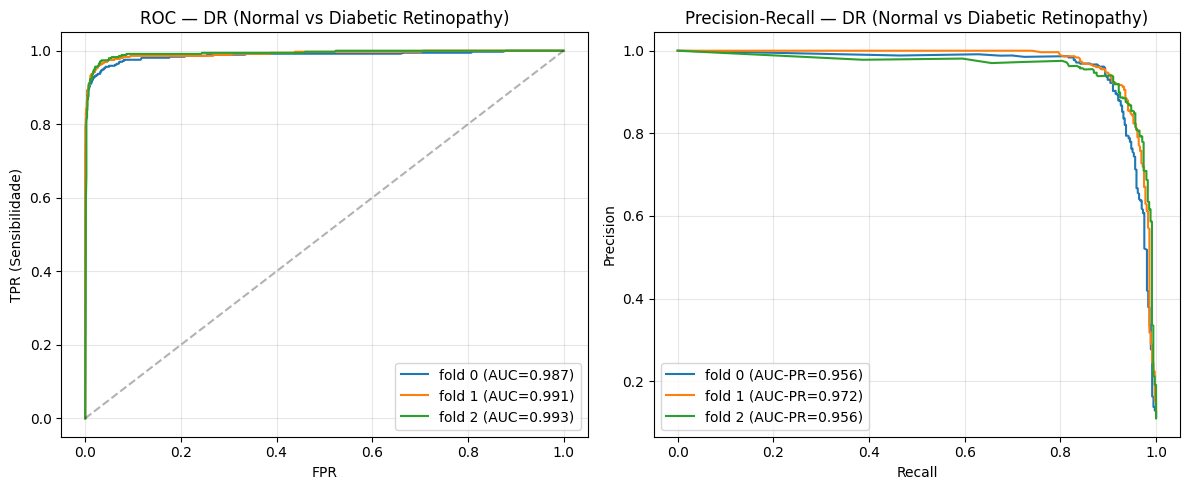

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for fold_idx in range(N_FOLDS):
    preds = pd.read_csv(os.path.join(OUTPUT_DIR, f"fold_{fold_idx}", "test_predictions.csv"))
    fpr, tpr, _ = roc_curve(preds["label"], preds["score"])
    pr, rc, _   = precision_recall_curve(preds["label"], preds["score"])
    axes[0].plot(fpr, tpr, label=f"fold {fold_idx} (AUC={sdf['auc_roc'][fold_idx]:.3f})")
    axes[1].plot(rc, pr,   label=f"fold {fold_idx} (AUC-PR={sdf['auc_pr'][fold_idx]:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="FPR", ylabel="TPR (Sensibilidade)", title=f"ROC — {TASK_NAME}")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision-Recall — {TASK_NAME}")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [20]:
from google.colab import runtime
runtime.unassign()